In [ ]:
"""
Exploratory testing of diffusion coefficients for AoA calculations using CESM2.1.5 output.
Not a functional takeaway as the clip is used too often to avoid negative values
and the tropical pipe/surf zone contrast needs refinement. 
See Plumb and Mahlman (1987).
"""

import numpy as np
import netCDF4 as nc

BASE = ('/data/cesm2.1.5_output/histSST/'
        'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
        'archive/atm/proc/tseries/month_1/')

# ── Load data ─────────────────────────────────────────────────────────────────
ds_n2o = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h0.N2O.199601-201412.nc')
ds_v   = nc.Dataset(BASE + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h0.V.199601-201412.nc')

print("N2O variables:", list(ds_n2o.variables.keys()))
print("V variables:",   list(ds_v.variables.keys()))

N2O = ds_n2o['N2O'][:]   
print('done')
V   = ds_v['V'][:]        

lev = ds_n2o['lev'][:]   
lat = ds_n2o['lat'][:]   

print(f"\nN2O shape: {N2O.shape}")
print(f"V shape:   {V.shape}")
print(f"lev range: {lev.min():.2f} to {lev.max():.2f}")
print(f"lat range: {lat.min():.1f} to {lat.max():.1f}")
print(f"N2O range: {N2O.min():.2e} to {N2O.max():.2e}")
print(f"V range:   {V.min():.2e} to {V.max():.2e}")

N2O variables: ['lat', 'zlon', 'zlon_bnds', 'gw', 'lon', 'lev', 'hyam', 'hybm', 'P0', 'ilev', 'hyai', 'hybi', 'ndbase', 'nsbase', 'nbdate', 'nbsec', 'mdt', 'time', 'date', 'datesec', 'time_bnds', 'date_written', 'time_written', 'ndcur', 'nscur', 'co2vmr', 'ch4vmr', 'n2ovmr', 'f11vmr', 'f12vmr', 'sol_tsi', 'nsteph', 'N2O']
V variables: ['lat', 'zlon', 'zlon_bnds', 'gw', 'lon', 'lev', 'hyam', 'hybm', 'P0', 'ilev', 'hyai', 'hybi', 'ndbase', 'nsbase', 'nbdate', 'nbsec', 'mdt', 'time', 'date', 'datesec', 'time_bnds', 'date_written', 'time_written', 'ndcur', 'nscur', 'co2vmr', 'ch4vmr', 'n2ovmr', 'f11vmr', 'f12vmr', 'sol_tsi', 'nsteph', 'V']
done

N2O shape: (228, 70, 192, 288)
V shape:   (228, 70, 192, 288)
lev range: 0.00 to 992.56
lat range: -90.0 to 90.0
N2O range: 2.68e-12 to 3.28e-07
V range:   -1.34e+02 to 1.36e+02


In [2]:
# ── Check which time indices are 1996 ─────────────────────────────────────────
dates = ds_n2o['date'][:]   # YYYYMMDD integers
print(f"First few dates: {dates[:6]}")
print(f"Last few dates:  {dates[-6:]}")

idx_1996 = np.where((dates >= 19960101) & (dates <= 19961231))[0]
print(f"1996 indices: {idx_1996}")
print(f"Number of 1996 months: {len(idx_1996)}")

# ── Check which levels are stratosphere ───────────────────────────────────────
print(f"\nlev values: {lev}")
# Stratosphere roughly lev < 100 hPa
strat_mask = lev < 100.0
print(f"Stratospheric levels: {lev[strat_mask]}")
print(f"Stratospheric level indices: {np.where(strat_mask)[0]}")

First few dates: [19960201 19960301 19960401 19960501 19960601 19960701]
Last few dates:  [20140801 20140901 20141001 20141101 20141201 20150101]
1996 indices: [ 0  1  2  3  4  5  6  7  8  9 10]
Number of 1996 months: 11

lev values: [5.96030003e-06 9.82690018e-06 1.62018505e-05 2.67122511e-05
 4.40410002e-05 7.26127478e-05 1.19719001e-04 1.97380004e-04
 3.25422505e-04 5.36532511e-04 8.84602485e-04 1.45845746e-03
 2.40457496e-03 3.97824988e-03 6.55682561e-03 1.08138256e-02
 1.78979999e-02 2.95577502e-02 4.87307498e-02 7.99107511e-02
 1.28273248e-01 1.98119997e-01 2.92025004e-01 4.10167500e-01
 5.53469989e-01 7.30479980e-01 9.55947500e-01 1.24479498e+00
 1.61285000e+00 2.07932497e+00 2.66742497e+00 3.40487505e+00
 4.32457495e+00 5.46539994e+00 6.87285000e+00 8.59972509e+00
 1.07070501e+01 1.32647501e+01 1.63517506e+01 2.00567506e+01
 2.44789999e+01 2.97279991e+01 3.59232500e+01 4.31937501e+01
 5.16774990e+01 6.15204982e+01 7.37509578e+01 8.78212303e+01
 1.03317127e+02 1.21547241e+02 1.4

In [3]:
# ── Subset to stratosphere proper (1-100 hPa) ─────────────────────────────────
strat_idx = np.where((lev >= 0.1) & (lev <= 100.0))[0]
print(f"Stratospheric level indices: {strat_idx}")
print(f"Corresponding lev values: {lev[strat_idx]}")

lev_start = strat_idx[0]
lev_end   = strat_idx[-1] + 1

print("Loading N2O...")
N2O = ds_n2o['N2O'][idx_1996[0]:idx_1996[-1]+1, lev_start:lev_end, :, :]
print(f"N2O shape: {N2O.shape}")

print("Loading V...")
V = ds_v['V'][idx_1996[0]:idx_1996[-1]+1, lev_start:lev_end, :, :]
print(f"V shape: {V.shape}")

lev_strat = lev[lev_start:lev_end]
print(f"lev_strat: {lev_strat}")
print(f"N2O range: {N2O.min():.2e} to {N2O.max():.2e}")
print(f"V range:   {V.min():.2e} to {V.max():.2e}")

Stratospheric level indices: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43
 44 45 46 47]
Corresponding lev values: [ 0.12827325  0.19812     0.292025    0.4101675   0.55346999  0.73047998
  0.9559475   1.24479498  1.61285     2.07932497  2.66742497  3.40487505
  4.32457495  5.46539994  6.87285     8.59972509 10.7070501  13.26475013
 16.35175059 20.05675063 24.4789999  29.72799912 35.92325002 43.19375008
 51.67749897 61.52049825 73.75095785 87.82123029]
Loading N2O...
N2O shape: (11, 28, 192, 288)
Loading V...
V shape: (11, 28, 192, 288)
lev_strat: [ 0.12827325  0.19812     0.292025    0.4101675   0.55346999  0.73047998
  0.9559475   1.24479498  1.61285     2.07932497  2.66742497  3.40487505
  4.32457495  5.46539994  6.87285     8.59972509 10.7070501  13.26475013
 16.35175059 20.05675063 24.4789999  29.72799912 35.92325002 43.19375008
 51.67749897 61.52049825 73.75095785 87.82123029]
N2O range: 1.17e-10 to 3.12e-07
V range:   -5.80e+01 to 5.82e+01


In [4]:
# ── Zonal mean ────────────────────────────────────────────────────────────────
N2O_zm = N2O.mean(axis=3)   # (11, 28, 192)
V_zm   = V.mean(axis=3)     # (11, 28, 192)

# ── Eddy flux v'q' = vq - v_zm*q_zm ─────────────────────────────────────────
VN2O_bar = (V * N2O).mean(axis=3)              # (11, 28, 192)
VN2O_eddy = (VN2O_bar - V_zm * N2O_zm).mean(axis=0)   # (28, 192) time mean
N2O_bar   = N2O_zm.mean(axis=0)                        # (28, 192) time mean

print(f"VN2O_eddy range: {VN2O_eddy.min():.2e} to {VN2O_eddy.max():.2e}")
print(f"N2O_bar range:   {N2O_bar.min():.2e} to {N2O_bar.max():.2e}")

# ── Meridional gradient ───────────────────────────────────────────────────────
lat_rad = np.deg2rad(lat)
r_earth = 6.371e6
dN2Ody  = np.gradient(N2O_bar, lat_rad * r_earth, axis=1)   # (28, 192)
print(f"dN2O/dy range: {dN2Ody.min():.2e} to {dN2Ody.max():.2e}")

# ── K_yy ─────────────────────────────────────────────────────────────────────
grad_threshold = np.percentile(np.abs(dN2Ody), 10)
dN2Ody_safe = np.where(np.abs(dN2Ody) > grad_threshold, dN2Ody, np.nan)
K_yy = -VN2O_eddy / dN2Ody_safe

print(f"\nK_yy range: {np.nanmin(K_yy):.2e} to {np.nanmax(K_yy):.2e} m²/s")
print(f"K_yy surf zone (30-60°): {np.nanmean(K_yy[:, (np.abs(lat)>30) & (np.abs(lat)<60)]):.2e}")
print(f"K_yy tropics (|lat|<20°): {np.nanmean(K_yy[:, np.abs(lat)<20]):.2e}")
print(f"K_yy positive fraction: {np.nansum(K_yy>0)/np.sum(~np.isnan(K_yy)):.2f}")

VN2O_eddy range: -1.99e-08 to 8.45e-09
N2O_bar range:   3.33e-10 to 3.10e-07
dN2O/dy range: -5.26e-14 to 4.02e-14

K_yy range: -2.22e+08 to 1.05e+08 m²/s
K_yy surf zone (30-60°): -5.92e+04
K_yy tropics (|lat|<20°): 5.17e+04
K_yy positive fraction: 0.48


/home/ubuntu/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [5]:
BASE_DAY = ('/data/cesm2.1.5_output/histSST/'
            'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001/'
            'archive/atm/proc/tseries/day_1/')

ds_co2 = nc.Dataset(BASE_DAY + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h7.CO2.19960101-20141231.nc')
ds_v7  = nc.Dataset(BASE_DAY + 'f.e21.FWHIST.f09_f09_mg17.atmos-scale_fixedSST_1996-2014.001.cam.h7.V.19960101-20141231.nc')

print(f"CO2 shape: {ds_co2['CO2'].shape}")
print(f"V shape:   {ds_v7['V'].shape}")
print(f"CO2 units: {ds_co2['CO2'].units}")
dates_h7 = ds_co2['date'][:]
print(f"First dates: {dates_h7[:5]}")
print(f"lev: {ds_co2['lev'][:]}")
ilev = ds_co2['ilev'][:]


CO2 shape: (6936, 70, 192, 288)
V shape:   (6936, 70, 192, 288)
CO2 units: mol/mol
First dates: [19960101 19960102 19960103 19960104 19960105]
lev: [5.96030003e-06 9.82690018e-06 1.62018505e-05 2.67122511e-05
 4.40410002e-05 7.26127478e-05 1.19719001e-04 1.97380004e-04
 3.25422505e-04 5.36532511e-04 8.84602485e-04 1.45845746e-03
 2.40457496e-03 3.97824988e-03 6.55682561e-03 1.08138256e-02
 1.78979999e-02 2.95577502e-02 4.87307498e-02 7.99107511e-02
 1.28273248e-01 1.98119997e-01 2.92025004e-01 4.10167500e-01
 5.53469989e-01 7.30479980e-01 9.55947500e-01 1.24479498e+00
 1.61285000e+00 2.07932497e+00 2.66742497e+00 3.40487505e+00
 4.32457495e+00 5.46539994e+00 6.87285000e+00 8.59972509e+00
 1.07070501e+01 1.32647501e+01 1.63517506e+01 2.00567506e+01
 2.44789999e+01 2.97279991e+01 3.59232500e+01 4.31937501e+01
 5.16774990e+01 6.15204982e+01 7.37509578e+01 8.78212303e+01
 1.03317127e+02 1.21547241e+02 1.42994039e+02 1.68225080e+02
 1.97908087e+02 2.32828619e+02 2.73910817e+02 3.22241902e+0

In [6]:
lev_h7 = ds_co2['lev'][:]
strat_idx_h7 = np.where((lev_h7 >= 1) & (lev_h7 <= 100.0))[0]
dates_h7 = ds_co2['date'][:]
idx_1996_h7 = np.where((dates_h7 >= 19960101) & (dates_h7 <= 19961231))[0]

print(f"1996: {len(idx_1996_h7)} days, indices {idx_1996_h7[0]} to {idx_1996_h7[-1]}")
print(f"Strat levels: {len(strat_idx_h7)}, indices {strat_idx_h7[0]} to {strat_idx_h7[-1]}")
print(f"lev_strat: {lev_h7[strat_idx_h7]}")

lev_start = strat_idx_h7[0]
lev_end   = strat_idx_h7[-1] + 1
t_start   = idx_1996_h7[0]
t_end     = idx_1996_h7[-1] + 1

print("\nLoading CO2...")
CO2 = ds_co2['CO2'][t_start:t_end, lev_start:lev_end, :, :]
print(f"CO2 shape: {CO2.shape}, range: {CO2.min():.2e} to {CO2.max():.2e}")

print("Loading V...")
V = ds_v7['V'][t_start:t_end, lev_start:lev_end, :, :]
print(f"V shape: {V.shape}, range: {V.min():.2e} to {V.max():.2e}")

1996: 365 days, indices 0 to 364
Strat levels: 21, indices 27 to 47
lev_strat: [ 1.24479498  1.61285     2.07932497  2.66742497  3.40487505  4.32457495
  5.46539994  6.87285     8.59972509 10.7070501  13.26475013 16.35175059
 20.05675063 24.4789999  29.72799912 35.92325002 43.19375008 51.67749897
 61.52049825 73.75095785 87.82123029]

Loading CO2...
CO2 shape: (365, 21, 192, 288), range: 3.51e-04 to 3.64e-04
Loading V...
V shape: (365, 21, 192, 288), range: -1.00e+02 to 1.00e+02


In [7]:
lat_h7 = ds_co2['lat'][:]
lat_rad = np.deg2rad(lat_h7)
r_earth = 6.371e6

# ── Eddy flux v'CO2' = vCO2 - v_zm * CO2_zm ──────────────────────────────────
CO2_zm = CO2.mean(axis=3)
V_zm   = V.mean(axis=3)
VCO2_bar  = (V * CO2).mean(axis=3)
VCO2_eddy = (VCO2_bar - V_zm * CO2_zm).mean(axis=0)   # (nlev, nlat)
CO2_bar   = CO2_zm.mean(axis=0)                        # (nlev, nlat)

# ── Meridional gradient ───────────────────────────────────────────────────────
dCO2dy = np.gradient(CO2_bar, lat_rad * r_earth, axis=1)

# ── K_yy (down-gradient) ──────────────────────────────────────────────────────
grad_threshold = np.percentile(np.abs(dCO2dy), 20)
dCO2dy_safe = np.where(np.abs(dCO2dy) > grad_threshold, dCO2dy, np.nan)
K_yy = -VCO2_eddy / dCO2dy_safe

# ── Post-process: floor, clip negatives, smooth (egusphere-2026-2772 step iii) ─
from scipy.ndimage import gaussian_filter

K_floor = 1.0e4
K_yy = np.where(K_yy < K_floor, K_floor, K_yy)   # clip negatives + tiny to floor
K_yy = np.where(np.isnan(K_yy), K_floor, K_yy)   # fill masked points
K_yy = gaussian_filter(K_yy, sigma=(1.0, 1.5))   # (lev, lat); tune sigma
K_yy = np.maximum(K_yy, K_floor)                 # re-impose floor after smoothing

print(f"K_yy range: {K_yy.min():.2e} to {K_yy.max():.2e} m²/s")
print(f"K_yy surf zone (30-60°): {K_yy[:, (np.abs(lat_h7)>30)&(np.abs(lat_h7)<60)].mean():.2e}")
print(f"K_yy tropics (|lat|<20°): {K_yy[:, np.abs(lat_h7)<20].mean():.2e}")

# ── Interpolate K_yy from h7 'lev' onto the solver's stratospheric grid ────────
# Solver grid: `ilev` (already masked/flipped to bottom→top) and `lat`.
# h7 source:   `lev_h7[strat_idx_h7]` (pressure, hPa) and `lat_h7`.
lev_src = np.asarray(lev_h7[strat_idx_h7], dtype=float)   # (nlev_src,) hPa

# match vertical orientation to solver's ilev (bottom→top = decreasing hPa)
if lev_src[0] < lev_src[-1]:          # source is top→bottom (increasing hPa)
    lev_src = lev_src[::-1]
    K_yy    = K_yy[::-1, :]

# 1) interpolate in latitude onto solver lat (if grids differ)
if not np.array_equal(lat_h7, lat):
    K_lat = np.empty((K_yy.shape[0], len(lat)))
    for iz in range(K_yy.shape[0]):
        K_lat[iz, :] = np.interp(lat, lat_h7, K_yy[iz, :])
else:
    K_lat = K_yy

# 2) interpolate in pressure onto solver ilev (log-p), per latitude column
logp_src = np.log(lev_src)
logp_dst = np.log(np.asarray(ilev, dtype=float))
K_yy_2d = np.empty((len(ilev), len(lat)))
for iy in range(len(lat)):
    K_yy_2d[:, iy] = np.interp(logp_dst, logp_src, K_lat[:, iy])

K_yy_2d = np.maximum(K_yy_2d, K_floor)
print(f"K_yy_2d (solver grid) shape: {K_yy_2d.shape}, "
      f"range: {K_yy_2d.min():.2e} to {K_yy_2d.max():.2e} m²/s")

K_yy range: 1.00e+04 to 1.98e+06 m²/s
K_yy surf zone (30-60°): 2.60e+05
K_yy tropics (|lat|<20°): 1.06e+05
K_yy_2d (solver grid) shape: (71, 192), range: 1.00e+04 to 6.58e+05 m²/s


Plotting at level: 51.7 hPa


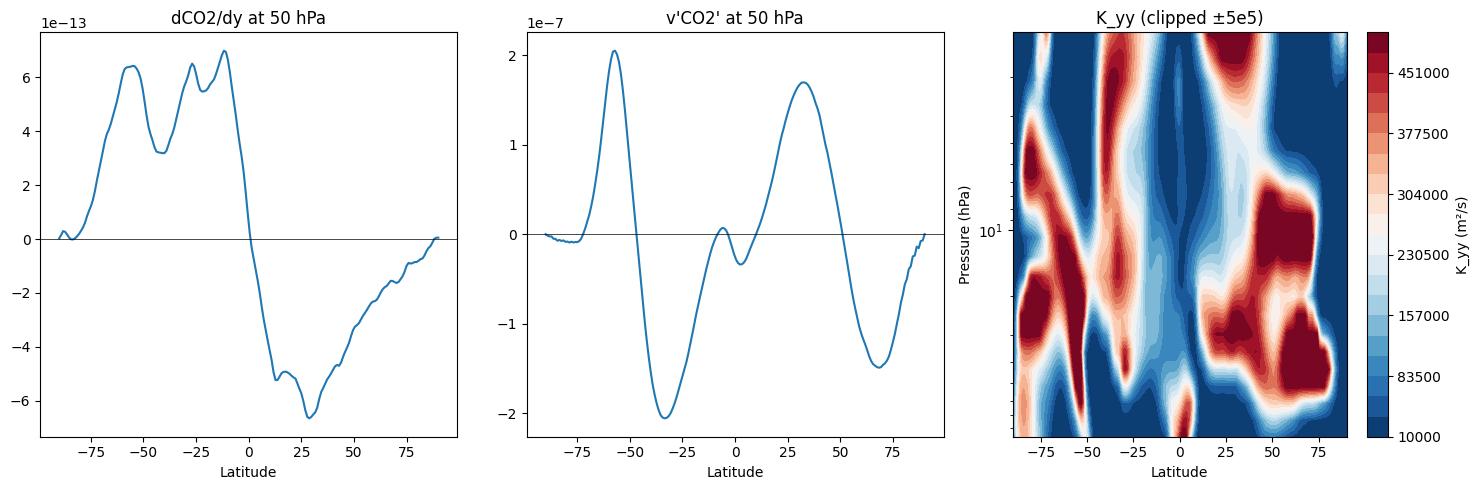

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

lev_idx = np.argmin(np.abs(lev_h7[strat_idx_h7] - 50.0))
print(f"Plotting at level: {lev_h7[strat_idx_h7][lev_idx]:.1f} hPa")

# ── CO2 gradient ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(lat_h7, dCO2dy[lev_idx, :])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('dCO2/dy at 50 hPa')
ax.set_xlabel('Latitude')

# ── Eddy flux ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(lat_h7, VCO2_eddy[lev_idx, :])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title("v'CO2' at 50 hPa")
ax.set_xlabel('Latitude')

# ── K_yy all levels ───────────────────────────────────────────────────────────
ax = axes[2]
K_clipped = np.clip(K_yy, -5e5, 5e5)
cf = ax.contourf(lat_h7, lev_h7[strat_idx_h7], K_clipped,
                 levels=np.linspace(1e4, 5e5, 21), cmap='RdBu_r')
plt.colorbar(cf, ax=ax, label='K_yy (m²/s)')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_title('K_yy (clipped ±5e5)')
ax.set_xlabel('Latitude')
ax.set_ylabel('Pressure (hPa)')

plt.tight_layout()
plt.show()